In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [21]:
def scl(df):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df1_scl = pd.DataFrame(scaler.fit_transform(df), columns = df.columns, index=df.index)
    return df1_scl
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)
    
    return data_encoded

def randomForest(X_train, X_test,y_train,y_test, n_estimators, max_depth):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix 

    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)


    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]


    importances = rf.feature_importances_
    feature_names = X_train.columns
    feat_importances = pd.DataFrame(importances, index=feature_names).reset_index().rename(columns={'index': 'Feature',0 : 'Importance'}).sort_values(by='Importance', ascending=False)
    # Calcular AUC y ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    # Matriz de confusión agregada
    cm = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm.ravel()

    # Métricas adicionales
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
    FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
    TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Random Forest')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Resultados
    # print r square de train y de test:
    r_squared = rf.score(X_train, y_train)
    print(f'R^2 train: {r_squared:.2f}')
    r_squared = rf.score(X_test, y_test)
    print(f'R^2 test: {r_squared:.2f}')


    accuracy = accuracy_score(y_test, y_test_pred)
    print(f'Accuracy: {accuracy:.2f}')

    print("AUC de la curva ROC:", roc_auc)
    print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
    print("Tasa de falsos negativos (FNR):", FNR)
    print("Tasa de verdaderos  positivos (TPR):", TPR)
    print("Tasa de falsos positivos (FPR):", FPR)
    print(feat_importances)

def ranfomForest_LOO(X_train, X_test,y_train,y_test, n_estimators, max_depth):
    from sklearn.model_selection import LeaveOneOut
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
    loo = LeaveOneOut()
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)

    y_train_pred = []
    y_test_pred = []
    y_test_proba = []
    accuracies_train = []
    accuracies_test = []
    importancias = []
    y_test_true = []
    for train_index, test_index in loo.split(X_train):
        X_train_loo, X_test_loo = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_loo, y_test_loo = y_train.iloc[train_index], y_train.iloc[test_index]

        rf.fit(X_train_loo, y_train_loo)
        y_train_pred_loo = rf.predict(X_train_loo)
        y_test_pred_loo = rf.predict(X_test_loo)
        y_test_proba_loo = rf.predict_proba(X_test_loo)[:, 1]

        # Guardar la predicción para análisis global
        y_test_true.append(y_test_loo.values[0])
        y_test_pred.append(y_test_pred_loo[0])
        y_test_proba.append(y_test_proba_loo[0])
        importancias.append(rf.feature_importances_)

        # Calcular precisión de esta iteración
        accuracies_train.append(accuracy_score(y_train_loo, y_train_pred_loo))
        accuracies_test.append(accuracy_score(y_test_loo, y_test_pred_loo))

    # Convertir listas a arrays
    y_train_pred = np.array(y_train_pred)
    y_test_pred = np.array(y_test_pred)
    y_test_proba = np.array(y_test_proba)
    importancias_df = pd.DataFrame(importancias, columns=X_train.columns)
    importancias_mean = importancias_df.mean().sort_values(ascending=False)
    
    # Calcular AUC y ROC
    fpr, tpr, thresholds = roc_curve(y_test_true, y_test_proba)
    roc_auc = auc(fpr, tpr)

    # Matriz de confusión agregada
    cm = confusion_matrix(y_test_true, y_test_pred)
    TN, FP, FN, TP = cm.ravel()

    # Métricas adicionales
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
    FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
    TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Random Forest (LOO CV)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Resultados
    print("Precisión media en entrenamiento:", np.mean(accuracies_train))
    print("Precisión media en test:", np.mean(accuracies_test))
    print("AUC de la curva ROC:", roc_auc)
    print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
    print("Tasa de falsos negativos (FNR):", FNR)
    print("Tasa de verdaderos  positivos (TPR):", TPR)
    print("Tasa de falsos positivos (FPR):", FPR)
    print(importancias_mean) 

def logistica (X_train, X_test,y_train,y_test, C = 1.2):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix
    log_reg = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C = C, random_state=1)



    # Entrenar el modelo
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    y_proba = log_reg.predict_proba(X_test)[:, 1] 

    accuracy = accuracy_score(y_test, y_pred)




    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)


    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    # Métricas adicionales
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
    FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
    TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan



    # Graficar la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Regresión Logística')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    print(f'Accuracy: {accuracy:.2f}')

    print(f'AUC: {roc_auc:.2f}')
    r_squared = log_reg.score(X_train, y_train)
    print(f'R^2 train: {r_squared:.2f}')
    r_squared = log_reg.score(X_test, y_test)
    print(f'R^2 test: {r_squared:.2f}')

    print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
    print("Tasa de falsos negativos (FNR):", FNR)
    print("Tasa de verdaderos  positivos (TPR):", TPR)
    print("Tasa de falsos positivos (FPR):", FPR)

    coefficients = pd.DataFrame({
        'Característica': X_train.columns,
        'Coeficiente': log_reg.coef_[0]
    })
    print("Coeficientes del modelo:")
    coefficients['absolute_coef'] = coefficients['Coeficiente'].abs()
    coefficients = coefficients.sort_values(by='absolute_coef', ascending=False).drop(columns='absolute_coef')
    print(coefficients)

In [3]:
lncRNA_seq = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
lncRNA_seq = lncRNA_seq.loc[:, ~lncRNA_seq.columns.str.contains('Norm')]
lncRNA_seq = lncRNA_seq.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
lncRNA_seq = lncRNA_seq[['TNRC6C-AS1', 'H19','MBNL1-AS1']]
lncRNA_seq.index = lncRNA_seq.index.str.replace('Raw_', '', regex=False)
#info adicional
lncRNA_seq_info = pd.read_csv('../mRNA_seq/pacientesInfoAdicional.csv',sep = ';')
lncRNA_seq_info['Sexo'] = lncRNA_seq_info['Sexo'].str.lower()
lncRNA_seq_info['Sexo'] = pd.get_dummies(lncRNA_seq_info['Sexo']).astype(int)['hombre']
lncRNA_seq_info = lncRNA_seq_info.drop('Condición', axis = 1).rename(columns = {'ID muestra': 'index'}).set_index('index')
lncRNA_seq = pd.merge(lncRNA_seq_info, lncRNA_seq, left_index=True, right_index=True).dropna()
lncRNA_seq['Normalizan'] = pd.get_dummies(lncRNA_seq['Normalizan']).astype(int)['si']
####validacion
lncRNA_qPCR = pd.read_excel('../mRNA_seq/Validation lncRNA  H19_TNRC6C_Mbnl1as1 040725.xlsx')
lncRNA_qPCR = lncRNA_qPCR.reset_index(drop=True).rename(columns ={'Unnamed: 0':'index','sexo' : 'Sexo','normalización' : 'Normalizan', 'Tnrc6cas1' : 'TNRC6C-AS1', 'Unnamed: 0':'index','Mbnl1as1':'MBNL1-AS1'}).dropna()
lncRNA_qPCR.set_index('index', inplace=True)
lncRNA_qPCR['Normalizan'] = lncRNA_qPCR['Normalizan'].str.strip()
lncRNA_qPCR['Sexo'] = lncRNA_qPCR['Sexo'].str.strip()
lncRNA_qPCR['Normalizan'] = pd.get_dummies(lncRNA_qPCR['Normalizan']).astype(int)['si']
lncRNA_qPCR['Sexo'] = pd.get_dummies(lncRNA_qPCR['Sexo']).astype(int)['hombre']
lncRNA_qPCR = lncRNA_qPCR[lncRNA_seq.columns]
## Estandarizar
lncRNA_qPCR_norm = scl(lncRNA_qPCR.drop(['Sexo', 'Normalizan'], axis=1))
lncRNA_seq_norm  = scl(lncRNA_seq.drop(['Sexo', 'Normalizan'], axis=1))
lncRNA_seq_norm = pd.concat([lncRNA_seq[['Sexo', 'Normalizan']], lncRNA_seq_norm], axis=1)
lncRNA_qPCR_norm = pd.concat([lncRNA_qPCR[['Sexo', 'Normalizan']], lncRNA_qPCR_norm], axis=1)


### Solo qPCR

In [49]:
X = lncRNA_qPCR_norm.drop(columns=["Normalizan"])
y = lncRNA_qPCR_norm["Normalizan"]

X_discretized = discretizar_variables(X.drop('Sexo', axis = 1), 2)
X = pd.concat([X['Sexo'], X_discretized], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

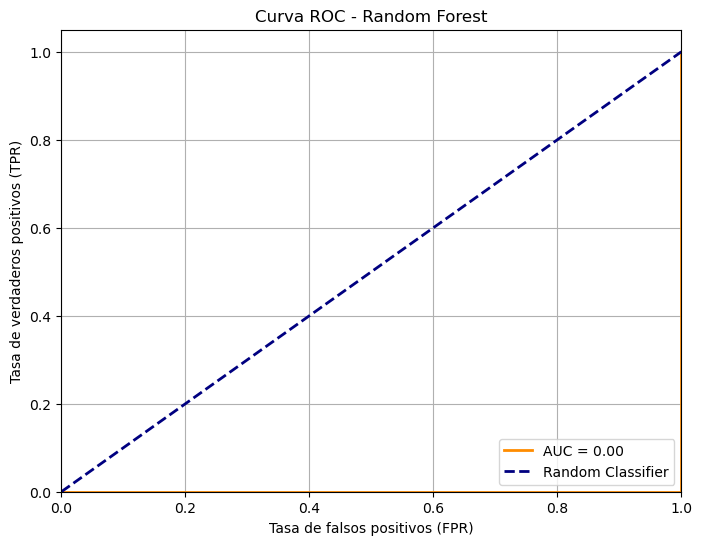

R^2 train: 0.87
R^2 test: 0.25
Accuracy: 0.25
AUC de la curva ROC: 0.0
Tasa de verdaderos negativos (TNR - especificidad): 0.3333333333333333
Tasa de falsos negativos (FNR): 1.0
Tasa de verdaderos  positivos (TPR): 0.0
Tasa de falsos positivos (FPR): 0.6666666666666666
        Feature  Importance
0          Sexo    0.297748
6   MBNL1-AS1_1    0.155385
5   MBNL1-AS1_0    0.151672
3         H19_0    0.121666
4         H19_1    0.104278
1  TNRC6C-AS1_0    0.091499
2  TNRC6C-AS1_1    0.077753


In [52]:
randomForest(X_train, X_test,y_train,y_test, 500,5)

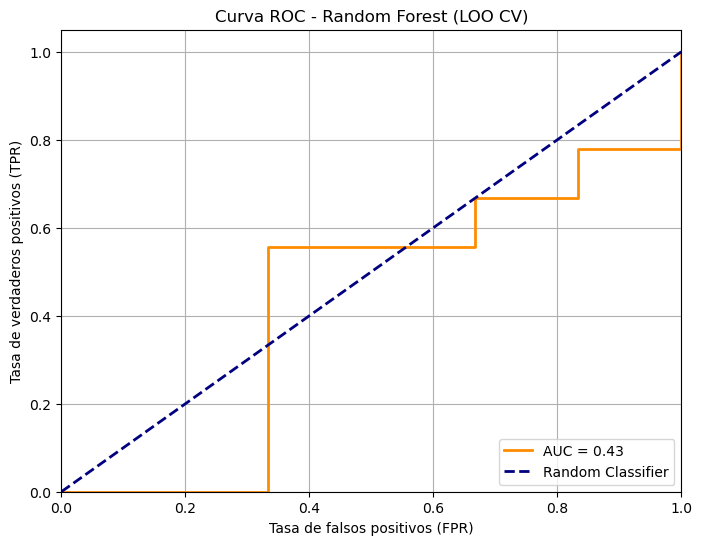

Precisión media en entrenamiento: 0.8666666666666668
Precisión media en test: 0.5333333333333333
AUC de la curva ROC: 0.42592592592592593
Tasa de verdaderos negativos (TNR - especificidad): 0.0
Tasa de falsos negativos (FNR): 0.1111111111111111
Tasa de verdaderos  positivos (TPR): 0.8888888888888888
Tasa de falsos positivos (FPR): 1.0
Sexo            0.300131
MBNL1-AS1_1     0.158134
MBNL1-AS1_0     0.143188
H19_0           0.120939
H19_1           0.107741
TNRC6C-AS1_0    0.086787
TNRC6C-AS1_1    0.083081
dtype: float64


In [19]:
ranfomForest_LOO(X_train, X_test,y_train,y_test, 500, 5)

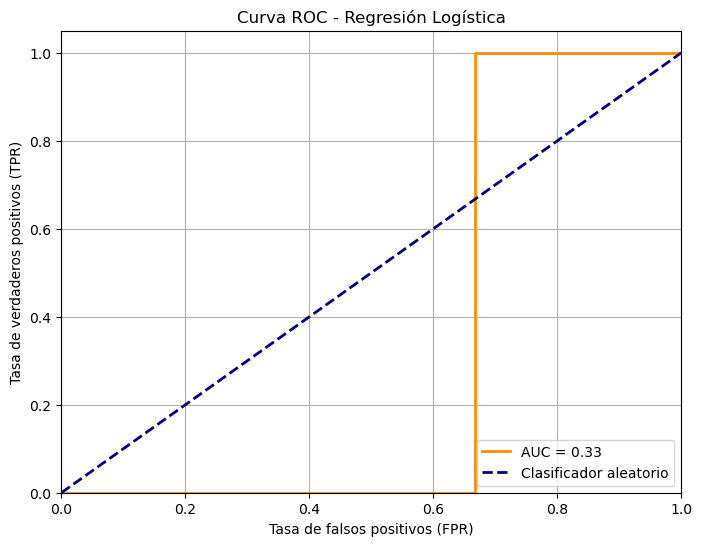

Accuracy: 0.25
AUC: 0.33
R^2 train: 0.53
R^2 test: 0.25
Tasa de verdaderos negativos (TNR - especificidad): 0.0
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 1.0
Coeficientes del modelo:
  Característica  Coeficiente
1   TNRC6C-AS1_0     0.103827
6    MBNL1-AS1_1    -0.091782
5    MBNL1-AS1_0     0.016610
2   TNRC6C-AS1_1    -0.004541
0           Sexo     0.000000
4          H19_1     0.000000
3          H19_0     0.000000


In [32]:
logistica(X_train, X_test,y_train,y_test, 1.5)

### Seq para entrenar y qpcr para validar 

In [33]:
X_train = lncRNA_seq_norm.drop(columns=["Normalizan"])
X_test = lncRNA_qPCR_norm.drop(columns=["Normalizan"])
y_train = lncRNA_seq_norm["Normalizan"]
y_test = lncRNA_qPCR_norm["Normalizan"]

X_train_discretized = discretizar_variables(X_train.drop('Sexo', axis = 1), 2)
X_test_discretized = discretizar_variables(X_test.drop('Sexo', axis = 1), 2)

X_train_discretized = pd.concat([X_train['Sexo'], X_train_discretized], axis=1)
X_test_discretized = pd.concat([X_test['Sexo'], X_test_discretized], axis=1)


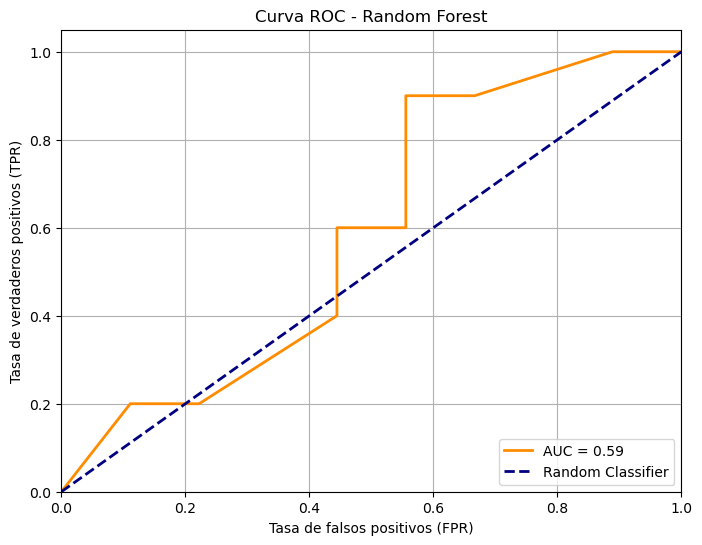

R^2 train: 0.83
R^2 test: 0.53
Accuracy: 0.53
AUC de la curva ROC: 0.5888888888888889
Tasa de verdaderos negativos (TNR - especificidad): 0.5555555555555556
Tasa de falsos negativos (FNR): 0.5
Tasa de verdaderos  positivos (TPR): 0.5
Tasa de falsos positivos (FPR): 0.4444444444444444
        Feature  Importance
0          Sexo    0.194987
6   MBNL1-AS1_1    0.157914
4         H19_1    0.148379
3         H19_0    0.145850
5   MBNL1-AS1_0    0.139680
1  TNRC6C-AS1_0    0.111554
2  TNRC6C-AS1_1    0.101636


In [34]:
randomForest(X_train_discretized, X_test_discretized, y_train, y_test, 500, 5)

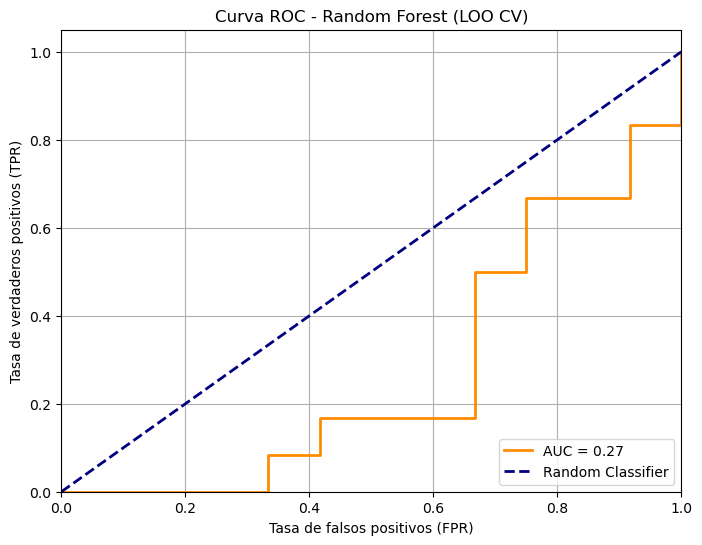

Precisión media en entrenamiento: 0.9764492753623187
Precisión media en test: 0.375
AUC de la curva ROC: 0.27083333333333337
Tasa de verdaderos negativos (TNR - especificidad): 0.3333333333333333
Tasa de falsos negativos (FNR): 0.5833333333333334
Tasa de verdaderos  positivos (TPR): 0.4166666666666667
Tasa de falsos positivos (FPR): 0.6666666666666666
TNRC6C-AS1    0.351609
H19           0.316453
MBNL1-AS1     0.305532
Sexo          0.026407
dtype: float64


In [36]:
ranfomForest_LOO(X_train, X_test,y_train,y_test, 500, 2)    

### Mezclando

In [37]:
df = pd.concat([lncRNA_seq_norm, lncRNA_qPCR_norm], axis=0)
df_discretized = discretizar_variables(df.drop(['Sexo', 'Normalizan'], axis=1), 2)
df_discretized = pd.concat([df_discretized, df[['Sexo', 'Normalizan']]], axis=1)
X = df_discretized.drop(columns=["Normalizan"])
y = df_discretized["Normalizan"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

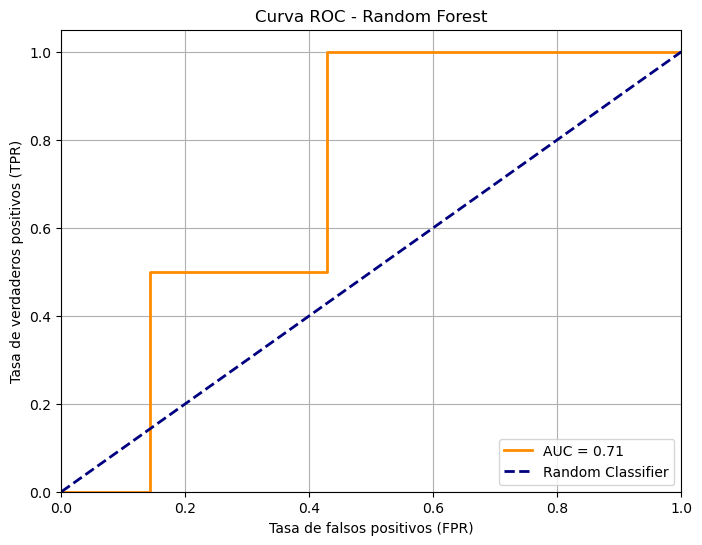

R^2 train: 0.74
R^2 test: 0.56
Accuracy: 0.56
AUC de la curva ROC: 0.7142857142857142
Tasa de verdaderos negativos (TNR - especificidad): 0.42857142857142855
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 0.5714285714285714
        Feature  Importance
6          Sexo    0.215967
4   MBNL1-AS1_0    0.155649
5   MBNL1-AS1_1    0.140983
1  TNRC6C-AS1_1    0.136226
3         H19_1    0.119866
2         H19_0    0.115685
0  TNRC6C-AS1_0    0.115624


In [40]:
randomForest(X_train, X_test, y_train, y_test, 200, 3)

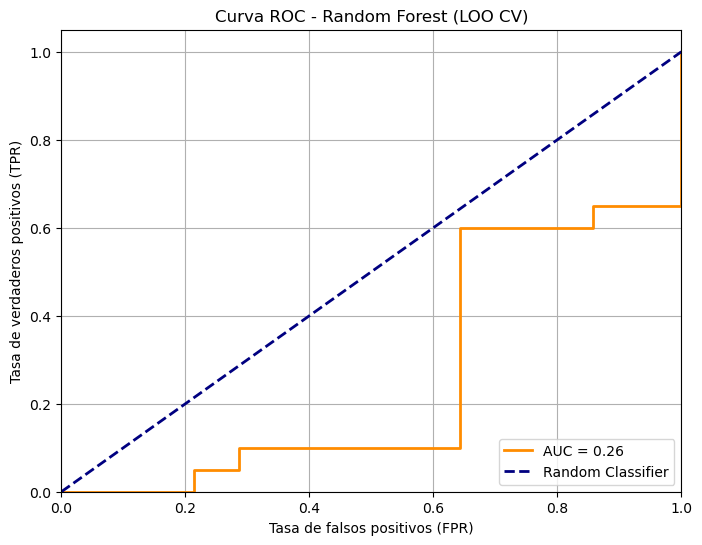

Precisión media en entrenamiento: 0.7370766488413547
Precisión media en test: 0.47058823529411764
AUC de la curva ROC: 0.2607142857142857
Tasa de verdaderos negativos (TNR - especificidad): 0.2857142857142857
Tasa de falsos negativos (FNR): 0.4
Tasa de verdaderos  positivos (TPR): 0.6
Tasa de falsos positivos (FPR): 0.7142857142857143
Sexo            0.227587
MBNL1-AS1_0     0.140040
MBNL1-AS1_1     0.139799
H19_1           0.128737
TNRC6C-AS1_0    0.124544
H19_0           0.121686
TNRC6C-AS1_1    0.117607
dtype: float64


In [41]:
ranfomForest_LOO(X_train, X_test,y_train,y_test, 200, 3)

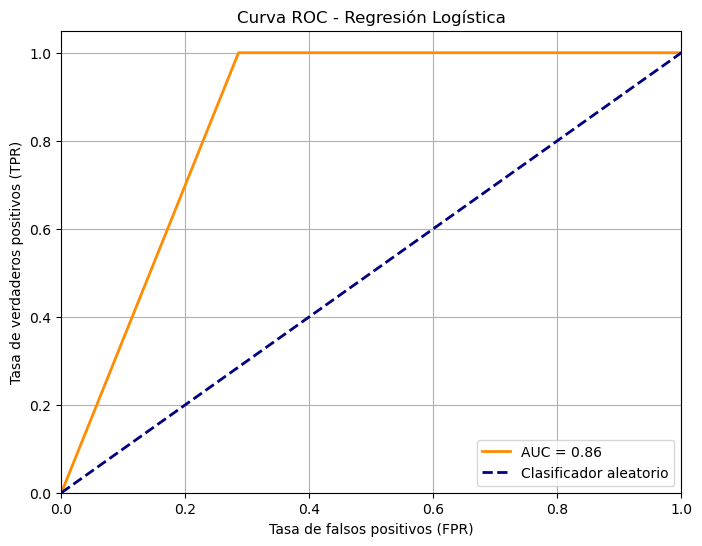

Accuracy: 0.78
AUC: 0.86
R^2 train: 0.59
R^2 test: 0.78
Tasa de verdaderos negativos (TNR - especificidad): 0.7142857142857143
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 0.2857142857142857
Coeficientes del modelo:
  Característica  Coeficiente
5    MBNL1-AS1_1    -0.151384
4    MBNL1-AS1_0     0.142944
0   TNRC6C-AS1_0     0.000000
2          H19_0     0.000000
1   TNRC6C-AS1_1     0.000000
3          H19_1     0.000000
6           Sexo     0.000000


In [42]:
logistica(X_train, X_test,y_train,y_test, 1.2)